In [29]:
# ============================================================
# 1. Imports
# ============================================================

import os
import json
import math
import time
import shutil
import hashlib
import platform
import datetime as dt
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.exceptions import ConvergenceWarning

import joblib
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

print("Python:", platform.python_version())
print("Platform:", platform.platform())

Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35


In [30]:
# ============================================================
# 2. Central configuration
# ============================================================

CONFIG = {
    # Experiment identity
    "project_name": "extremism_text_classification",
    "technique_name": "LOG-REG_TF-IDF",
    "model_family": "logistic_regression",
    "feature_family": "tfidf_word",
    "dataset_version": "extremism_dataset_clean_v1",
    "split_version": "split_v1",
    "random_seed": 30,

    # Paths
    # Leave these as None to auto-discover the files under /kaggle/input or /kaggle/working.
    # If auto-discovery fails, paste the exact paths from Kaggle's file browser.
    "processed_dataset_path": "/kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/processed_dataset.csv",
    "split_assignments_path": "/kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/split_assignments.csv",
    "dataset_manifest_path": "/kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/dataset_manifest.json",

    # Required columns from 00_create_dataset_and_splits.ipynb
    "id_col": "row_id",
    "text_col": "text",
    "label_col": "label",
    "split_col": "split",
    "positive_label": 1,

    # Output
    "output_root": "/kaggle/working/experiments",
    "overwrite_output_dir": True,

    # Ablation / tuning
    # Keep this grid modest and comparable across techniques.
    "ablation_grid": {
        "max_features": [10000, 20000, 50000],
        "ngram_range": [[1, 1], [1, 2], [1, 3]],
        "min_df": [1, 2, 5],
        "max_df": [0.95],
        "sublinear_tf": [True],
        "C": [0.1, 1.0, 3.0, 10.0],
        "class_weight": [None, "balanced"],
    },

    # Model settings
    "logreg": {
        "solver": "liblinear",
        "penalty": "l2",
        "max_iter": 3000,
        "random_state": 30,
    },

    # Thresholding
    # Recommended default: maximize validation positive-class F1.
    "threshold_strategy": "maximize_val_f1",
    "threshold_grid": {
        "start": 0.01,
        "stop": 0.99,
        "num": 99,
    },

    # Explainability
    "explainability": {
        "top_n_global": 100,
        "top_k_local_features": 15,
        "max_local_examples_total": 120,
        "include_text_preview": False,
        "text_preview_chars": 240,
    },

    # Error analysis
    "error_analysis": {
        "examples_per_bucket": 25,
        "near_threshold_margin": 0.05,
        "include_text_preview": False,
        "text_preview_chars": 240,
    },
}

TECHNIQUE_NAME = CONFIG["technique_name"]
OUTPUT_DIR = Path(CONFIG["output_root"]) / TECHNIQUE_NAME

print("Technique:", TECHNIQUE_NAME)
print("Output directory:", OUTPUT_DIR)

Technique: LOG-REG_TF-IDF
Output directory: /kaggle/working/experiments/LOG-REG_TF-IDF


In [31]:
# ============================================================
# 3. Reproducibility and helper functions
# ============================================================

def set_global_seed(seed: int) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def make_json_safe(obj):
    """Convert numpy/scipy/path objects into JSON-serializable Python objects."""
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        if math.isnan(float(obj)):
            return None
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if pd.isna(obj) if not isinstance(obj, (list, tuple, dict, np.ndarray)) else False:
        return None
    return obj

def save_json(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(make_json_safe(obj), f, indent=2)

def sha256_file(path: Path, n_chars: int = 16) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()[:n_chars]

def sha256_text(text: str, n_chars: int = 16) -> str:
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()[:n_chars]

def find_file_by_name(file_name: str, search_roots=None) -> Path:
    """Find a file under common Kaggle locations. Raises a clear error if not found."""
    if search_roots is None:
        search_roots = [Path("/kaggle/input"), Path("/kaggle/working"), Path(".")]

    matches = []
    for root in search_roots:
        if root.exists():
            matches.extend(root.rglob(file_name))

    matches = sorted(set(matches), key=lambda p: (len(str(p)), str(p)))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find {file_name}.\n"
            "Set CONFIG['processed_dataset_path'] or CONFIG['split_assignments_path'] manually."
        )

    print(f"Found {file_name}:")
    for m in matches[:10]:
        print(" -", m)
    if len(matches) > 1:
        print(f"Using first match: {matches[0]}")
    return matches[0]

def initialize_output_dir(output_dir: Path, overwrite: bool = True) -> None:
    if output_dir.exists() and overwrite:
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for subdir in [
        "model_artifacts",
        "plots",
        "interpretability",
        "error_analysis",
        "ablation",
    ]:
        (output_dir / subdir).mkdir(parents=True, exist_ok=True)

set_global_seed(CONFIG["random_seed"])
initialize_output_dir(OUTPUT_DIR, CONFIG["overwrite_output_dir"])

save_json(CONFIG, OUTPUT_DIR / "config.json")

print("Initialized output directory.")

Initialized output directory.


In [32]:
# ============================================================
# 4. Load processed dataset, split assignments, and manifest
# ============================================================

processed_dataset_path = (
    Path(CONFIG["processed_dataset_path"])
    if CONFIG["processed_dataset_path"] is not None
    else find_file_by_name("processed_dataset.csv")
)

split_assignments_path = (
    Path(CONFIG["split_assignments_path"])
    if CONFIG["split_assignments_path"] is not None
    else find_file_by_name("split_assignments.csv")
)

if CONFIG["dataset_manifest_path"] is not None:
    dataset_manifest_path = Path(CONFIG["dataset_manifest_path"])
else:
    try:
        dataset_manifest_path = find_file_by_name("dataset_manifest.json")
    except FileNotFoundError:
        dataset_manifest_path = None

df = pd.read_csv(processed_dataset_path)
splits = pd.read_csv(split_assignments_path)

print("Processed dataset path:", processed_dataset_path)
print("Split assignments path:", split_assignments_path)
print("Dataset shape:", df.shape)
print("Splits shape:", splits.shape)

display(df.head())
display(splits.head())

dataset_manifest = {}
if dataset_manifest_path is not None and dataset_manifest_path.exists():
    with open(dataset_manifest_path, "r") as f:
        dataset_manifest = json.load(f)
    print("Loaded dataset manifest:", dataset_manifest_path)
else:
    print("No dataset manifest found. Continuing without it.")

Processed dataset path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/processed_dataset.csv
Split assignments path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/split_assignments.csv
Dataset shape: (2999, 8)
Splits shape: (2999, 4)


,row_id,original_index,text,label,raw_label,text_hash,char_len,word_len
0,ex_000000,0,sixth forms should burn to the ground,1,EXTREMIST,e0cc81a4d5f0f2b3,37,7
1,ex_000001,1,whatever should burn benders to the ground,1,EXTREMIST,906f97390ef91f64,42,7
2,ex_000002,2,factories should burn to the ground,1,EXTREMIST,50fe44bc8cf60d1c,35,6
3,ex_000003,3,halal factories should burn to the ground,1,EXTREMIST,4bedb3fea5ed5fbe,41,7
4,ex_000004,4,nhs should burn to the ground,1,EXTREMIST,f1a8b2543327a925,29,6


,row_id,label,text_hash,split
0,ex_000000,1,e0cc81a4d5f0f2b3,test
1,ex_000001,1,906f97390ef91f64,train
2,ex_000002,1,50fe44bc8cf60d1c,validation
3,ex_000003,1,4bedb3fea5ed5fbe,validation
4,ex_000004,1,f1a8b2543327a925,validation


Loaded dataset manifest: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/dataset_manifest.json


In [33]:
# ============================================================
# 5. Validate schema and apply canonical split
# ============================================================

id_col = CONFIG["id_col"]
text_col = CONFIG["text_col"]
label_col = CONFIG["label_col"]
split_col = CONFIG["split_col"]

required_df_cols = {id_col, text_col, label_col}
required_split_cols = {id_col, split_col}

missing_df_cols = required_df_cols - set(df.columns)
missing_split_cols = required_split_cols - set(splits.columns)

if missing_df_cols:
    raise ValueError(f"Processed dataset is missing required columns: {missing_df_cols}")
if missing_split_cols:
    raise ValueError(f"Split assignments are missing required columns: {missing_split_cols}")

# Defensive cleaning.
df = df.copy()
df[text_col] = df[text_col].fillna("").astype(str)
df[label_col] = df[label_col].astype(int)

# Apply split file.
df = df.merge(splits[[id_col, split_col]], on=id_col, how="left", validate="one_to_one")

if df[split_col].isna().any():
    missing = int(df[split_col].isna().sum())
    raise ValueError(f"{missing} rows in processed_dataset.csv do not have split assignments.")

expected_splits = {"train", "validation", "test"}
actual_splits = set(df[split_col].unique())
if actual_splits != expected_splits:
    raise ValueError(f"Expected splits {expected_splits}, found {actual_splits}")

train_df = df[df[split_col] == "train"].copy()
val_df = df[df[split_col] == "validation"].copy()
test_df = df[df[split_col] == "test"].copy()

print("Split sizes:")
display(df[split_col].value_counts().to_frame("count"))

print("\nLabel distribution by split:")
split_label_table = (
    df.groupby([split_col, label_col])
    .size()
    .reset_index(name="count")
)
split_sizes = df.groupby(split_col).size().rename("split_count").reset_index()
split_label_table = split_label_table.merge(split_sizes, on=split_col)
split_label_table["proportion"] = split_label_table["count"] / split_label_table["split_count"]
display(split_label_table)

assert train_df[id_col].is_unique
assert val_df[id_col].is_unique
assert test_df[id_col].is_unique
assert set(train_df[id_col]).isdisjoint(set(val_df[id_col]))
assert set(train_df[id_col]).isdisjoint(set(test_df[id_col]))
assert set(val_df[id_col]).isdisjoint(set(test_df[id_col]))

print("Split validation passed.")

Split sizes:


,count
split,
train,2099
test,450
validation,450



Label distribution by split:


,split,label,count,split_count,proportion
0,test,0,280,450,0.622222
1,test,1,170,450,0.377778
2,train,0,1309,2099,0.623630
3,train,1,790,2099,0.376370
4,validation,0,281,450,0.624444
5,validation,1,169,450,0.375556


Split validation passed.


In [34]:
# ============================================================
# 7. Build ablation grid
# ============================================================

def expand_ablation_grid(grid_dict):
    keys = list(grid_dict.keys())
    values = [grid_dict[k] for k in keys]
    configs = []
    for combo in product(*values):
        cfg = dict(zip(keys, combo))
        # Make ngram_range a tuple for sklearn.
        cfg["ngram_range"] = tuple(cfg["ngram_range"])
        configs.append(cfg)
    return configs

ablation_configs = expand_ablation_grid(CONFIG["ablation_grid"])

print(f"Number of ablation configurations: {len(ablation_configs)}")
display(pd.DataFrame([make_json_safe(c) for c in ablation_configs]).head(20))

Number of ablation configurations: 216


,max_features,ngram_range,min_df,max_df,sublinear_tf,C,class_weight
0,10000,"[1, 1]",1,0.95,True,0.1,None
1,10000,"[1, 1]",1,0.95,True,0.1,balanced
2,10000,"[1, 1]",1,0.95,True,1.0,None
3,10000,"[1, 1]",1,0.95,True,1.0,balanced
4,10000,"[1, 1]",1,0.95,True,3.0,None
5,10000,"[1, 1]",1,0.95,True,3.0,balanced
6,10000,"[1, 1]",1,0.95,True,10.0,None
7,10000,"[1, 1]",1,0.95,True,10.0,balanced
8,10000,"[1, 1]",2,0.95,True,0.1,None
9,10000,"[1, 1]",2,0.95,True,0.1,balanced


In [35]:
# ============================================================
# 6. Metric and threshold utilities
# ============================================================

def safe_roc_auc(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_prob)
    except Exception:
        return np.nan

def safe_pr_auc(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return average_precision_score(y_true, y_prob)
    except Exception:
        return np.nan

def compute_binary_metrics(y_true, y_prob, threshold, positive_label=1):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    labels = [0, 1]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=labels).ravel()

    metrics = {
        "threshold": float(threshold),
        "support": int(len(y_true)),
        "positive_support": int((y_true == positive_label).sum()),
        "negative_support": int((y_true != positive_label).sum()),
        "positive_rate": float((y_true == positive_label).mean()),

        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "positive_precision": float(precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "positive_recall": float(recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "positive_f1": float(f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "roc_auc": float(safe_roc_auc(y_true, y_prob)),
        "pr_auc": float(safe_pr_auc(y_true, y_prob)),
        "brier_score": float(brier_score_loss(y_true, y_prob)),

        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
        "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan,
    }
    return metrics

def choose_threshold(y_true, y_prob, strategy="maximize_val_f1", threshold_grid_config=None):
    if strategy == "fixed_0.5":
        return 0.5, {"strategy": strategy, "selected_threshold": 0.5}

    if threshold_grid_config is None:
        threshold_grid_config = {"start": 0.01, "stop": 0.99, "num": 99}

    thresholds = np.linspace(
        threshold_grid_config["start"],
        threshold_grid_config["stop"],
        threshold_grid_config["num"],
    )

    rows = []
    for threshold in thresholds:
        metrics = compute_binary_metrics(
            y_true=y_true,
            y_prob=y_prob,
            threshold=float(threshold),
            positive_label=CONFIG["positive_label"],
        )
        rows.append(metrics)

    threshold_df = pd.DataFrame(rows)

    if strategy == "maximize_val_f1":
        sort_cols = ["positive_f1", "pr_auc", "positive_recall", "positive_precision"]
        threshold_df = threshold_df.sort_values(sort_cols, ascending=[False, False, False, False])
        best_row = threshold_df.iloc[0].to_dict()
        return float(best_row["threshold"]), {
            "strategy": strategy,
            "selected_threshold": float(best_row["threshold"]),
            "selection_table": threshold_df,
            "selected_validation_metrics": best_row,
        }

    raise ValueError(f"Unknown threshold strategy: {strategy}")

def make_predictions_frame(split_name, split_df, y_prob, threshold, technique_name):
    y_true = split_df[label_col].values.astype(int)
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)

    out = pd.DataFrame({
        "run_id": RUN_ID,
        "technique": technique_name,
        "row_id": split_df[id_col].values,
        "split": split_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_score": np.asarray(y_prob).astype(float),
        "y_prob": np.asarray(y_prob).astype(float),
        "threshold": float(threshold),
        "correct": (y_true == y_pred),
    })

    def error_type(row):
        if row["y_true"] == 0 and row["y_pred"] == 1:
            return "false_positive"
        if row["y_true"] == 1 and row["y_pred"] == 0:
            return "false_negative"
        if row["y_true"] == 1 and row["y_pred"] == 1:
            return "true_positive"
        return "true_negative"

    out["error_type"] = out.apply(error_type, axis=1)

    if "text_hash" in split_df.columns:
        out["text_hash"] = split_df["text_hash"].values
    else:
        out["text_hash"] = split_df[text_col].apply(sha256_text).values

    return out

print("Metric and threshold utilities ready.")

Metric and threshold utilities ready.


In [38]:
# ============================================================
# 7b. OPTIONAL FAST PATH -- load a previously trained model from disk
# ============================================================
# Run this cell INSTEAD of the cells from "8. Validation-only ablation" through
# "14. Save model artifacts" below, if model_artifacts/ from a previous run of this
# notebook already exists (e.g. reattached as a Kaggle input, or still present in
# /kaggle/working). It reconstructs everything those cells produce -- final_vectorizer,
# final_model, feature_names, X_train_final/X_val_final/X_test_final, selected_threshold,
# and validation_predictions/test_predictions -- without repeating the hyperparameter
# search or refitting the model.
#
# If you do NOT have a previous run's artifacts, skip this cell entirely and run the
# notebook normally from "8. Validation-only ablation" onward.

PREVIOUS_RUN_ARTIFACTS_DIR = Path("/kaggle/input/datasets/adityasureshgithub//extremism-sentiment-analysis-model-artifacts/01_model_outputs/01_LOG-REG_TF-IDF/LOG-REG_TF-IDF_outputs/model_artifacts")  # point this at a differe
                                                              # path/Kaggle input if loading
                                                              # artifacts from another run
RUN_ID = f"{TECHNIQUE_NAME}_{dt.datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"
final_vectorizer = joblib.load(PREVIOUS_RUN_ARTIFACTS_DIR / "vectorizer.pkl")
final_model = joblib.load(PREVIOUS_RUN_ARTIFACTS_DIR / "model.pkl")

feature_names = pd.read_csv(
    PREVIOUS_RUN_ARTIFACTS_DIR / "feature_names.txt", header=None
)[0].to_numpy()

X_train_final = final_vectorizer.transform(train_df[text_col].tolist())
X_val_final = final_vectorizer.transform(val_df[text_col].tolist())
X_test_final = final_vectorizer.transform(test_df[text_col].tolist())

with open(PREVIOUS_RUN_ARTIFACTS_DIR / "threshold.json") as f:
    selected_threshold = json.load(f)["selected_threshold"]

val_prob = final_model.predict_proba(X_val_final)[:, 1]
test_prob = final_model.predict_proba(X_test_final)[:, 1]

print("RUN_ID" in dir())
print("TECHNIQUE_NAME" in dir())
print("OUTPUT_DIR" in dir())

validation_predictions = make_predictions_frame(
    split_name="validation",
    split_df=val_df,
    y_prob=val_prob,
    threshold=selected_threshold,
    technique_name=TECHNIQUE_NAME,
)
test_predictions = make_predictions_frame(
    split_name="test",
    split_df=test_df,
    y_prob=test_prob,
    threshold=selected_threshold,
    technique_name=TECHNIQUE_NAME,
)

print("Loaded model artifacts from:", PREVIOUS_RUN_ARTIFACTS_DIR)
print("Vectorizer vocabulary size:", len(feature_names))
print("Selected threshold (from previous run):", selected_threshold)
print("You can now skip ahead to the interpretability / SHAP cells --")
print("the ablation and final-training cells below are not needed.")



/tmp/ipykernel_58/1675591261.py:18: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  RUN_ID = f"{TECHNIQUE_NAME}_{dt.datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"


True
True
True
Loaded model artifacts from: /kaggle/input/datasets/adityasureshgithub/extremism-sentiment-analysis-model-artifacts/01_model_outputs/01_LOG-REG_TF-IDF/LOG-REG_TF-IDF_outputs/model_artifacts
Vectorizer vocabulary size: 50000
Selected threshold (from previous run): 0.45
You can now skip ahead to the interpretability / SHAP cells --
the ablation and final-training cells below are not needed.


In [8]:
# ============================================================
# 8. Validation-only ablation / hyperparameter tuning
# ============================================================

RUN_ID = f"{TECHNIQUE_NAME}_{dt.datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"
print("Run ID:", RUN_ID)

X_train_text = train_df[text_col].tolist()
y_train = train_df[label_col].values.astype(int)

X_val_text = val_df[text_col].tolist()
y_val = val_df[label_col].values.astype(int)

ablation_rows = []
trained_count = 0
start_time = time.time()

for i, cfg in enumerate(ablation_configs, start=1):
    print(f"\n[{i}/{len(ablation_configs)}] {cfg}")

    iter_start = time.time()

    vectorizer = TfidfVectorizer(
        max_features=cfg["max_features"],
        ngram_range=cfg["ngram_range"],
        min_df=cfg["min_df"],
        max_df=cfg["max_df"],
        sublinear_tf=cfg["sublinear_tf"],
        lowercase=True,
        strip_accents=None,
        dtype=np.float32,
    )

    X_train_vec = vectorizer.fit_transform(X_train_text)
    X_val_vec = vectorizer.transform(X_val_text)

    model = LogisticRegression(
        C=cfg["C"],
        class_weight=cfg["class_weight"],
        solver=CONFIG["logreg"]["solver"],
        penalty=CONFIG["logreg"]["penalty"],
        max_iter=CONFIG["logreg"]["max_iter"],
        random_state=CONFIG["random_seed"],
    )

    model.fit(X_train_vec, y_train)

    val_prob = model.predict_proba(X_val_vec)[:, 1]

    selected_threshold, threshold_info = choose_threshold(
        y_true=y_val,
        y_prob=val_prob,
        strategy=CONFIG["threshold_strategy"],
        threshold_grid_config=CONFIG["threshold_grid"],
    )

    val_metrics = compute_binary_metrics(
        y_true=y_val,
        y_prob=val_prob,
        threshold=selected_threshold,
        positive_label=CONFIG["positive_label"],
    )

    elapsed = time.time() - iter_start

    row = {
        "run_id": RUN_ID,
        "technique": TECHNIQUE_NAME,
        "config_index": i,
        "selection_metric": "validation_positive_f1",
        "fit_seconds": elapsed,
        "num_features_fit": int(X_train_vec.shape[1]),
        **make_json_safe(cfg),
        **{f"validation_{k}": v for k, v in val_metrics.items()},
    }
    ablation_rows.append(row)
    trained_count += 1

    print(
        f"validation positive_f1={val_metrics['positive_f1']:.4f}, "
        f"precision={val_metrics['positive_precision']:.4f}, "
        f"recall={val_metrics['positive_recall']:.4f}, "
        f"pr_auc={val_metrics['pr_auc']:.4f}, "
        f"threshold={selected_threshold:.3f}, "
        f"features={X_train_vec.shape[1]}, "
        f"time={elapsed:.1f}s"
    )

ablation_results = pd.DataFrame(ablation_rows)

# Model-selection rule: highest validation positive F1.
# Tie-breakers: PR-AUC, positive recall, positive precision, then simpler feature space.
ablation_results = ablation_results.sort_values(
    by=[
        "validation_positive_f1",
        "validation_pr_auc",
        "validation_positive_recall",
        "validation_positive_precision",
        "num_features_fit",
    ],
    ascending=[False, False, False, False, True],
).reset_index(drop=True)

ablation_path = OUTPUT_DIR / "ablation" / "ablation_results.csv"
ablation_results.to_csv(ablation_path, index=False)

print("\nAblation complete.")
print(f"Trained configurations: {trained_count}")
print(f"Total tuning time: {(time.time() - start_time) / 60:.2f} minutes")
print("Saved:", ablation_path)

display(ablation_results.head(10))

Run ID: LOG-REG_TF-IDF_20260627_195218

[1/216] {'max_features': 10000, 'ngram_range': (1, 1), 'min_df': 1, 'max_df': 0.95, 'sublinear_tf': True, 'C': 0.1, 'class_weight': None}


/tmp/ipykernel_23/3580424483.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  RUN_ID = f"{TECHNIQUE_NAME}_{dt.datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"


validation positive_f1=0.7003, precision=0.7500, recall=0.6568, pr_auc=0.8120, threshold=0.390, features=6313, time=1.4s

[2/216] {'max_features': 10000, 'ngram_range': (1, 1), 'min_df': 1, 'max_df': 0.95, 'sublinear_tf': True, 'C': 0.1, 'class_weight': 'balanced'}
validation positive_f1=0.7044, precision=0.7517, recall=0.6627, pr_auc=0.8148, threshold=0.500, features=6313, time=1.2s

[3/216] {'max_features': 10000, 'ngram_range': (1, 1), 'min_df': 1, 'max_df': 0.95, 'sublinear_tf': True, 'C': 1.0, 'class_weight': None}
validation positive_f1=0.7335, precision=0.7111, recall=0.7574, pr_auc=0.8411, threshold=0.390, features=6313, time=1.2s

[4/216] {'max_features': 10000, 'ngram_range': (1, 1), 'min_df': 1, 'max_df': 0.95, 'sublinear_tf': True, 'C': 1.0, 'class_weight': 'balanced'}
validation positive_f1=0.7341, precision=0.7175, recall=0.7515, pr_auc=0.8412, threshold=0.500, features=6313, time=1.3s

[5/216] {'max_features': 10000, 'ngram_range': (1, 1), 'min_df': 1, 'max_df': 0.95, 's

,run_id,technique,config_index,selection_metric,fit_seconds,num_features_fit,max_features,ngram_range,min_df,max_df,sublinear_tf,C,class_weight,validation_threshold,validation_support,validation_positive_support,validation_negative_support,validation_positive_rate,validation_accuracy,validation_balanced_accuracy,validation_positive_precision,validation_positive_recall,validation_positive_f1,validation_macro_f1,validation_weighted_f1,validation_roc_auc,validation_pr_auc,validation_brier_score,validation_tn,validation_fp,validation_fn,validation_tp,validation_false_positive_rate,validation_false_negative_rate
0,LOG-REG_TF-IDF_20260627_195218,LOG-REG_TF-IDF,199,validation_positive_f1,1.405282,50000,50000,"[1, 3]",1,0.95,True,10.0,None,0.45,450,169,281,0.375556,0.824444,0.809903,0.774390,0.751479,0.762763,0.811716,0.823901,0.888353,0.853352,0.127454,244,37,42,127,0.131673,0.248521
1,LOG-REG_TF-IDF_20260627_195218,LOG-REG_TF-IDF,200,validation_positive_f1,1.424425,50000,50000,"[1, 3]",1,0.95,True,10.0,balanced,0.53,450,169,281,0.375556,0.822222,0.808124,0.769697,0.751479,0.760479,0.809568,0.821786,0.888816,0.853323,0.130890,243,38,42,127,0.135231,0.248521
2,LOG-REG_TF-IDF_20260627_195218,LOG-REG_TF-IDF,103,validation_positive_f1,1.381311,20000,20000,"[1, 2]",1,0.95,True,10.0,None,0.48,450,169,281,0.375556,0.826667,0.806966,0.793548,0.727811,0.759259,0.811921,0.825028,0.888522,0.852689,0.128092,249,32,46,123,0.113879,0.272189
3,LOG-REG_TF-IDF_20260627_195218,LOG-REG_TF-IDF,104,validation_positive_f1,1.395473,20000,20000,"[1, 2]",1,0.95,True,10.0,balanced,0.56,450,169,281,0.375556,0.826667,0.806966,0.793548,0.727811,0.759259,0.811921,0.825028,0.888985,0.852327,0.131631,249,32,46,123,0.113879,0.272189
4,LOG-REG_TF-IDF_20260627_195218,LOG-REG_TF-IDF,198,validation_positive_f1,1.402919,50000,50000,"[1, 3]",1,0.95,True,3.0,balanced,0.51,450,169,281,0.375556,0.817778,0.804565,0.760479,0.751479,0.755952,0.805281,0.817559,0.887700,0.852793,0.134639,241,40,42,127,0.142349,0.248521
5,LOG-REG_TF-IDF_20260627_195218,LOG-REG_TF-IDF,197,validation_positive_f1,1.420241,50000,50000,"[1, 3]",1,0.95,True,3.0,None,0.42,450,169,281,0.375556,0.817778,0.804565,0.760479,0.751479,0.755952,0.805281,0.817559,0.886711,0.851595,0.129743,241,40,42,127,0.142349,0.248521
6,LOG-REG_TF-IDF_20260627_195218,LOG-REG_TF-IDF,128,validation_positive_f1,1.530835,20000,20000,"[1, 3]",1,0.95,True,10.0,balanced,0.52,450,169,281,0.375556,0.817778,0.803386,0.763636,0.745562,0.754491,0.804807,0.817331,0.888522,0.852702,0.132056,242,39,43,126,0.138790,0.254438
7,LOG-REG_TF-IDF_20260627_195218,LOG-REG_TF-IDF,127,validation_positive_f1,1.475770,20000,20000,"[1, 3]",1,0.95,True,10.0,None,0.44,450,169,281,0.375556,0.815556,0.802786,0.755952,0.751479,0.753709,0.803142,0.815446,0.888121,0.852294,0.128465,240,41,42,127,0.145907,0.248521
8,LOG-REG_TF-IDF_20260627_195218,LOG-REG_TF-IDF,176,validation_positive_f1,1.377977,32281,50000,"[1, 2]",1,0.95,True,10.0,balanced,0.56,450,169,281,0.375556,0.820000,0.800449,0.782051,0.721893,0.750769,0.804950,0.818435,0.886500,0.852702,0.132299,247,34,47,122,0.120996,0.278107
9,LOG-REG_TF-IDF_20260627_195218,LOG-REG_TF-IDF,125,validation_positive_f1,1.460754,20000,20000,"[1, 3]",1,0.95,True,3.0,None,0.42,450,169,281,0.375556,0.811111,0.799227,0.747059,0.751479,0.749263,0.798874,0.811221,0.888458,0.853143,0.128381,238,43,42,127,0.153025,0.248521


In [9]:
# ============================================================
# 9. Select best configuration from validation results
# ============================================================

best_row = ablation_results.iloc[0].to_dict()

best_config = {
    "technique_name": TECHNIQUE_NAME,
    "model_family": CONFIG["model_family"],
    "feature_family": CONFIG["feature_family"],
    "selection_rule": {
        "primary": "highest validation positive_f1",
        "tie_breakers": [
            "higher validation pr_auc",
            "higher validation positive_recall",
            "higher validation positive_precision",
            "fewer fitted features",
        ],
    },
    "selected_from_config_index": int(best_row["config_index"]),
    "tfidf": {
        "max_features": int(best_row["max_features"]),
        "ngram_range": list(best_row["ngram_range"]) if isinstance(best_row["ngram_range"], tuple) else best_row["ngram_range"],
        "min_df": int(best_row["min_df"]),
        "max_df": float(best_row["max_df"]),
        "sublinear_tf": bool(best_row["sublinear_tf"]),
        "lowercase": True,
        "strip_accents": None,
    },
    "model": {
        "C": float(best_row["C"]),
        "class_weight": best_row["class_weight"],
        "solver": CONFIG["logreg"]["solver"],
        "penalty": CONFIG["logreg"]["penalty"],
        "max_iter": CONFIG["logreg"]["max_iter"],
        "random_state": CONFIG["random_seed"],
    },
    "selected_validation_metrics": {
        k.replace("validation_", ""): v
        for k, v in best_row.items()
        if k.startswith("validation_")
    },
}

save_json(best_config, OUTPUT_DIR / "best_config.json")

print("Best configuration:")
print(json.dumps(make_json_safe(best_config), indent=2))

Best configuration:
{
  "technique_name": "LOG-REG_TF-IDF",
  "model_family": "logistic_regression",
  "feature_family": "tfidf_word",
  "selection_rule": {
    "primary": "highest validation positive_f1",
    "tie_breakers": [
      "higher validation pr_auc",
      "higher validation positive_recall",
      "higher validation positive_precision",
      "fewer fitted features"
    ]
  },
  "selected_from_config_index": 199,
  "tfidf": {
    "max_features": 50000,
    "ngram_range": [
      1,
      3
    ],
    "min_df": 1,
    "max_df": 0.95,
    "sublinear_tf": true,
    "lowercase": true,
    "strip_accents": null
  },
  "model": {
    "C": 10.0,
    "class_weight": null,
    "solver": "liblinear",
    "penalty": "l2",
    "max_iter": 3000,
    "random_state": 30
  },
  "selected_validation_metrics": {
    "threshold": 0.45,
    "support": 450,
    "positive_support": 169,
    "negative_support": 281,
    "positive_rate": 0.37555555555555553,
    "accuracy": 0.8244444444444444,
   

In [10]:
# ============================================================
# 10. Train final locked model using the selected configuration
# ============================================================

# Important:
# The final model is trained on the train split only.
# The validation split remains separate for threshold selection.
# The test split is used only once, after the threshold is locked.

tfidf_cfg = best_config["tfidf"]
model_cfg = best_config["model"]

final_vectorizer = TfidfVectorizer(
    max_features=tfidf_cfg["max_features"],
    ngram_range=tuple(tfidf_cfg["ngram_range"]),
    min_df=tfidf_cfg["min_df"],
    max_df=tfidf_cfg["max_df"],
    sublinear_tf=tfidf_cfg["sublinear_tf"],
    lowercase=tfidf_cfg["lowercase"],
    strip_accents=tfidf_cfg["strip_accents"],
    dtype=np.float32,
)

X_train_final = final_vectorizer.fit_transform(train_df[text_col].tolist())
X_val_final = final_vectorizer.transform(val_df[text_col].tolist())
X_test_final = final_vectorizer.transform(test_df[text_col].tolist())

final_model = LogisticRegression(
    C=model_cfg["C"],
    class_weight=model_cfg["class_weight"],
    solver=model_cfg["solver"],
    penalty=model_cfg["penalty"],
    max_iter=model_cfg["max_iter"],
    random_state=model_cfg["random_state"],
)

final_start = time.time()
final_model.fit(X_train_final, train_df[label_col].values.astype(int))
final_fit_seconds = time.time() - final_start

feature_names = np.array(final_vectorizer.get_feature_names_out())

print("Final model trained.")
print("Train matrix:", X_train_final.shape)
print("Validation matrix:", X_val_final.shape)
print("Test matrix:", X_test_final.shape)
print("Final fitted features:", len(feature_names))
print(f"Final fit time: {final_fit_seconds:.2f}s")

Final model trained.
Train matrix: (2099, 50000)
Validation matrix: (450, 50000)
Test matrix: (450, 50000)
Final fitted features: 50000
Final fit time: 0.04s


In [11]:
# ============================================================
# 11. Select threshold on validation split only
# ============================================================

val_prob = final_model.predict_proba(X_val_final)[:, 1]

selected_threshold, threshold_info = choose_threshold(
    y_true=val_df[label_col].values.astype(int),
    y_prob=val_prob,
    strategy=CONFIG["threshold_strategy"],
    threshold_grid_config=CONFIG["threshold_grid"],
)

validation_metrics = compute_binary_metrics(
    y_true=val_df[label_col].values.astype(int),
    y_prob=val_prob,
    threshold=selected_threshold,
    positive_label=CONFIG["positive_label"],
)

save_json(validation_metrics, OUTPUT_DIR / "metrics_validation.json")

threshold_metadata = {
    "threshold_strategy": CONFIG["threshold_strategy"],
    "selected_threshold": selected_threshold,
    "selected_on_split": "validation",
    "validation_metrics_at_selected_threshold": validation_metrics,
}

save_json(threshold_metadata, OUTPUT_DIR / "model_artifacts" / "threshold.json")

# Save threshold search table if available.
if "selection_table" in threshold_info:
    threshold_info["selection_table"].to_csv(
        OUTPUT_DIR / "ablation" / "validation_threshold_search.csv",
        index=False,
    )

print("Selected threshold:", selected_threshold)
print("Validation metrics:")
print(json.dumps(make_json_safe(validation_metrics), indent=2))

Selected threshold: 0.45
Validation metrics:
{
  "threshold": 0.45,
  "support": 450,
  "positive_support": 169,
  "negative_support": 281,
  "positive_rate": 0.37555555555555553,
  "accuracy": 0.8244444444444444,
  "balanced_accuracy": 0.8099033460380298,
  "positive_precision": 0.774390243902439,
  "positive_recall": 0.7514792899408284,
  "positive_f1": 0.7627627627627628,
  "macro_f1": 0.811716478383145,
  "weighted_f1": 0.8239005142708846,
  "roc_auc": 0.8883530922950579,
  "pr_auc": 0.8533520048687385,
  "brier_score": 0.12745447642616253,
  "tn": 244,
  "fp": 37,
  "fn": 42,
  "tp": 127,
  "false_positive_rate": 0.13167259786476868,
  "false_negative_rate": 0.2485207100591716
}


In [12]:
# ============================================================
# 12. Final held-out test evaluation
# ============================================================

test_prob = final_model.predict_proba(X_test_final)[:, 1]

test_metrics = compute_binary_metrics(
    y_true=test_df[label_col].values.astype(int),
    y_prob=test_prob,
    threshold=selected_threshold,
    positive_label=CONFIG["positive_label"],
)

metrics_test = {
    "run_id": RUN_ID,
    "technique": TECHNIQUE_NAME,
    "model_family": CONFIG["model_family"],
    "feature_family": CONFIG["feature_family"],
    "dataset_version": CONFIG["dataset_version"],
    "split_version": CONFIG["split_version"],
    "random_seed": CONFIG["random_seed"],
    "trained_on_split": "train",
    "threshold_selected_on_split": "validation",
    "evaluated_on_split": "test",
    "final_fit_seconds": final_fit_seconds,
    **test_metrics,
}

save_json(metrics_test, OUTPUT_DIR / "metrics_test.json")

test_pred = (test_prob >= selected_threshold).astype(int)
classification_report_test = classification_report(
    test_df[label_col].values.astype(int),
    test_pred,
    labels=[0, 1],
    target_names=["non_extremist", "extremist"],
    output_dict=True,
    zero_division=0,
)
save_json(classification_report_test, OUTPUT_DIR / "classification_report_test.json")

cm = confusion_matrix(test_df[label_col].values.astype(int), test_pred, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=["actual_non_extremist", "actual_extremist"],
    columns=["pred_non_extremist", "pred_extremist"],
)
cm_df.to_csv(OUTPUT_DIR / "confusion_matrix_test.csv")

print("Final held-out test metrics:")
print(json.dumps(make_json_safe(metrics_test), indent=2))

print("\nConfusion matrix:")
display(cm_df)

Final held-out test metrics:
{
  "run_id": "LOG-REG_TF-IDF_20260627_195218",
  "technique": "LOG-REG_TF-IDF",
  "model_family": "logistic_regression",
  "feature_family": "tfidf_word",
  "dataset_version": "extremism_dataset_clean_v1",
  "split_version": "split_v1",
  "random_seed": 30,
  "trained_on_split": "train",
  "threshold_selected_on_split": "validation",
  "evaluated_on_split": "test",
  "final_fit_seconds": 0.036184072494506836,
  "threshold": 0.45,
  "support": 450,
  "positive_support": 170,
  "negative_support": 280,
  "positive_rate": 0.37777777777777777,
  "accuracy": 0.8533333333333334,
  "balanced_accuracy": 0.840546218487395,
  "positive_precision": 0.8170731707317073,
  "positive_recall": 0.788235294117647,
  "positive_f1": 0.8023952095808383,
  "macro_f1": 0.8428937178646241,
  "weighted_f1": 0.8527933532228829,
  "roc_auc": 0.9111344537815126,
  "pr_auc": 0.8881319077697478,
  "brier_score": 0.11160293035803355,
  "tn": 250,
  "fp": 30,
  "fn": 36,
  "tp": 134,
  "

,pred_non_extremist,pred_extremist
actual_non_extremist,250,30
actual_extremist,36,134


In [13]:
# ============================================================
# 13. Save standardized prediction files
# ============================================================

validation_predictions = make_predictions_frame(
    split_name="validation",
    split_df=val_df,
    y_prob=val_prob,
    threshold=selected_threshold,
    technique_name=TECHNIQUE_NAME,
)

test_predictions = make_predictions_frame(
    split_name="test",
    split_df=test_df,
    y_prob=test_prob,
    threshold=selected_threshold,
    technique_name=TECHNIQUE_NAME,
)

validation_predictions.to_csv(OUTPUT_DIR / "predictions_validation.csv", index=False)
test_predictions.to_csv(OUTPUT_DIR / "predictions_test.csv", index=False)

print("Saved prediction files:")
print("-", OUTPUT_DIR / "predictions_validation.csv")
print("-", OUTPUT_DIR / "predictions_test.csv")

display(test_predictions.head())
display(test_predictions["error_type"].value_counts().to_frame("count"))

Saved prediction files:
- /kaggle/working/experiments/LOG-REG_TF-IDF/predictions_validation.csv
- /kaggle/working/experiments/LOG-REG_TF-IDF/predictions_test.csv


,run_id,technique,row_id,split,y_true,y_pred,y_score,y_prob,threshold,correct,error_type,text_hash
0,LOG-REG_TF-IDF_20260627_195218,LOG-REG_TF-IDF,ex_000000,test,1,1,0.847635,0.847635,0.45,True,true_positive,e0cc81a4d5f0f2b3
1,LOG-REG_TF-IDF_20260627_195218,LOG-REG_TF-IDF,ex_000012,test,1,1,0.953165,0.953165,0.45,True,true_positive,1c94926b81fc81a8
2,LOG-REG_TF-IDF_20260627_195218,LOG-REG_TF-IDF,ex_000021,test,1,0,0.335974,0.335974,0.45,False,false_negative,aaaf481f25917405
3,LOG-REG_TF-IDF_20260627_195218,LOG-REG_TF-IDF,ex_000023,test,1,1,0.838851,0.838851,0.45,True,true_positive,4fb27b01defd61d6
4,LOG-REG_TF-IDF_20260627_195218,LOG-REG_TF-IDF,ex_000034,test,0,0,0.192004,0.192004,0.45,True,true_negative,024bc26847a63b8a


,count
error_type,
true_negative,250
true_positive,134
false_negative,36
false_positive,30


In [14]:
# ============================================================
# 14. Save model artifacts
# ============================================================

joblib.dump(final_model, OUTPUT_DIR / "model_artifacts" / "model.pkl")
joblib.dump(final_vectorizer, OUTPUT_DIR / "model_artifacts" / "vectorizer.pkl")

pd.Series(feature_names, name="feature_name").to_csv(
    OUTPUT_DIR / "model_artifacts" / "feature_names.txt",
    index=False,
    header=False,
)

model_metadata = {
    "run_id": RUN_ID,
    "technique": TECHNIQUE_NAME,
    "model_family": CONFIG["model_family"],
    "feature_family": CONFIG["feature_family"],
    "num_features": int(len(feature_names)),
    "coef_shape": list(final_model.coef_.shape),
    "intercept": final_model.intercept_.tolist(),
    "selected_threshold": selected_threshold,
    "final_fit_seconds": final_fit_seconds,
}

save_json(model_metadata, OUTPUT_DIR / "model_artifacts" / "model_metadata.json")

print("Model artifacts saved.")

Model artifacts saved.


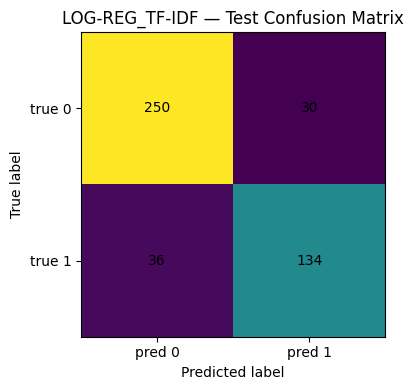

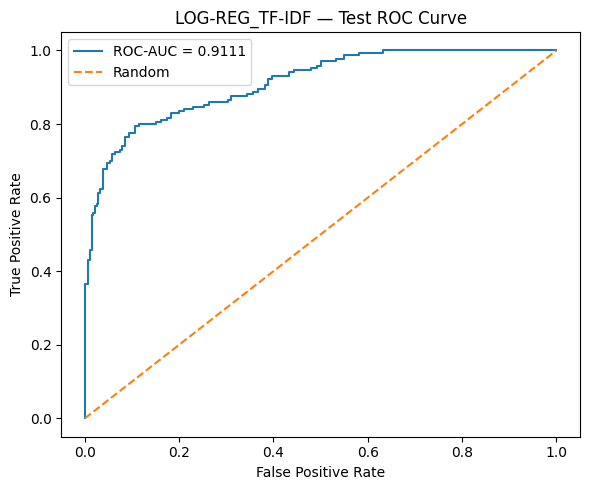

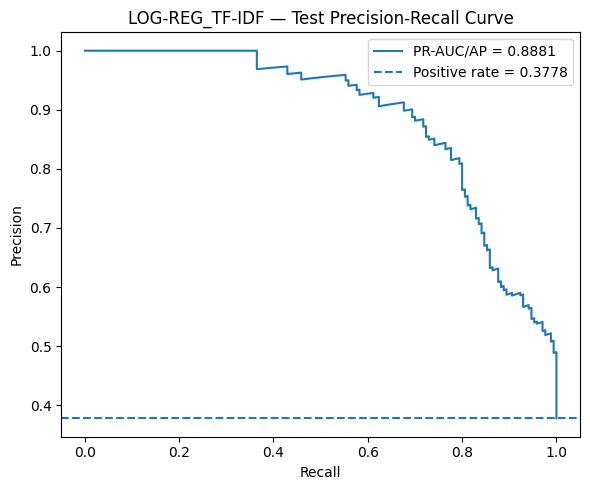

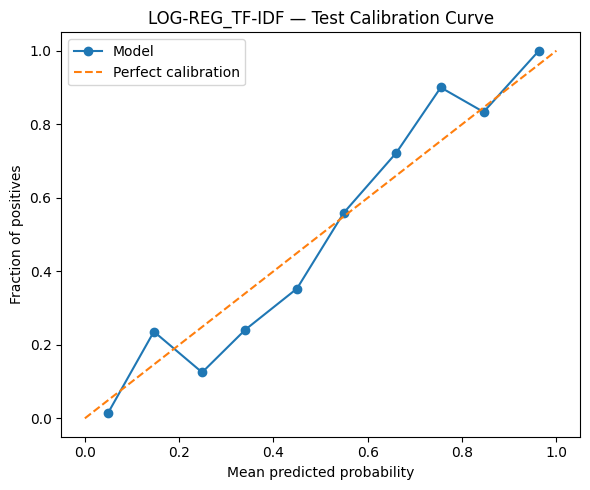

In [15]:
# ============================================================
# 15. Diagnostic plots
# ============================================================

def save_confusion_matrix_plot(cm, path: Path):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["pred 0", "pred 1"])
    ax.set_yticklabels(["true 0", "true 1"])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"{TECHNIQUE_NAME} — Test Confusion Matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()

def save_roc_plot(y_true, y_prob, path: Path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = safe_roc_auc(y_true, y_prob)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, label=f"ROC-AUC = {auc_val:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{TECHNIQUE_NAME} — Test ROC Curve")
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()

def save_pr_plot(y_true, y_prob, path: Path):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = safe_pr_auc(y_true, y_prob)
    baseline = np.mean(y_true)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall, precision, label=f"PR-AUC/AP = {ap:.4f}")
    ax.axhline(baseline, linestyle="--", label=f"Positive rate = {baseline:.4f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{TECHNIQUE_NAME} — Test Precision-Recall Curve")
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()

def save_calibration_plot(y_true, y_prob, path: Path, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="uniform")

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(prob_pred, prob_true, marker="o", label="Model")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"{TECHNIQUE_NAME} — Test Calibration Curve")
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()

y_test = test_df[label_col].values.astype(int)

save_confusion_matrix_plot(cm, OUTPUT_DIR / "plots" / "confusion_matrix_test.png")
save_roc_plot(y_test, test_prob, OUTPUT_DIR / "plots" / "roc_curve_test.png")
save_pr_plot(y_test, test_prob, OUTPUT_DIR / "plots" / "pr_curve_test.png")
save_calibration_plot(y_test, test_prob, OUTPUT_DIR / "plots" / "calibration_curve_test.png")

In [39]:
# ============================================================
# 16. Global interpretability: logistic regression coefficients and contributions
# ============================================================

coef = final_model.coef_.ravel()
intercept = float(final_model.intercept_[0])

global_coef_df = pd.DataFrame({
    "feature_name": feature_names,
    "coefficient": coef,
    "abs_coefficient": np.abs(coef),
})

# Positive coefficients push toward extremist class.
top_positive = (
    global_coef_df
    .sort_values("coefficient", ascending=False)
    .head(CONFIG["explainability"]["top_n_global"])
    .reset_index(drop=True)
)

top_negative = (
    global_coef_df
    .sort_values("coefficient", ascending=True)
    .head(CONFIG["explainability"]["top_n_global"])
    .reset_index(drop=True)
)

# Contribution-based importance considers how much features actually appear in test examples.
# contribution = tfidf_value * coefficient
test_contrib = X_test_final.multiply(coef)
mean_abs_contrib = np.asarray(np.abs(test_contrib).mean(axis=0)).ravel()

global_contrib_df = pd.DataFrame({
    "feature_name": feature_names,
    "coefficient": coef,
    "mean_abs_test_contribution": mean_abs_contrib,
})
global_contrib_df = global_contrib_df.sort_values(
    "mean_abs_test_contribution",
    ascending=False,
).reset_index(drop=True)

top_positive.to_csv(OUTPUT_DIR / "interpretability" / "top_positive_features_by_coefficient.csv", index=False)
top_negative.to_csv(OUTPUT_DIR / "interpretability" / "top_negative_features_by_coefficient.csv", index=False)
global_contrib_df.head(CONFIG["explainability"]["top_n_global"]).to_csv(
    OUTPUT_DIR / "interpretability" / "top_features_by_mean_abs_test_contribution.csv",
    index=False,
)

global_importance = global_contrib_df.copy()
global_importance["rank_by_mean_abs_contribution"] = np.arange(1, len(global_importance) + 1)
global_importance.to_csv(OUTPUT_DIR / "interpretability" / "global_importance.csv", index=False)

explanation_metadata = {
    "method": "linear_logistic_regression_tfidf_contributions",
    "logit_formula": "logit = intercept + sum(tfidf_j * coefficient_j)",
    "local_contribution_formula": "contribution_j = tfidf_value_j * coefficient_j",
    "explained_scale": "logit / log-odds for positive class",
    "positive_class": "extremist",
    "negative_class": "non_extremist",
    "caveat": "Features are TF-IDF n-grams, not causal explanations or semantic concepts.",
}
save_json(explanation_metadata, OUTPUT_DIR / "interpretability" / "explanation_metadata.json")

print("Top positive features:")
display(top_positive.head(20))

print("\nTop negative features:")
display(top_negative.head(20))

print("\nTop features by mean absolute test contribution:")
display(global_contrib_df.head(20))

Top positive features:


,feature_name,coefficient,abs_coefficient
0,kill,6.636001,6.636001
1,are,4.186493,4.186493
2,ill,4.168297,4.168297
3,genocide,4.032097,4.032097
4,white,3.789301,3.789301
5,should,3.727083,3.727083
6,shoot,3.563303,3.563303
7,see,3.350738,3.350738
8,people,3.259985,3.259985
9,islam,3.182179,3.182179



Top negative features:


,feature_name,coefficient,abs_coefficient
0,bitch,-7.240914,7.240914
1,trumpisatraitor,-3.591193,3.591193
2,me,-3.357801,3.357801
3,trump,-2.957964,2.957964
4,ass,-2.721231,2.721231
5,traitor,-2.580593,2.580593
6,retarded,-2.457028,2.457028
7,hoe,-2.416387,2.416387
8,for,-2.370489,2.370489
9,when,-2.281412,2.281412



Top features by mean absolute test contribution:


,feature_name,coefficient,mean_abs_test_contribution
0,bitch,-7.240914,0.176232
1,are,4.186493,0.094492
2,kill,6.636001,0.086167
3,of,3.117001,0.074455
4,you,-2.024163,0.068369
5,people,3.259985,0.048097
6,the,1.344806,0.044218
7,that,-1.765155,0.035797
8,for,-2.370489,0.034132
9,they,2.191418,0.031015


In [40]:
# ============================================================
# 17. Local interpretability for selected test examples
# ============================================================

def get_local_linear_explanation(row_index_in_split, X_matrix, feature_names, coef, top_k=15):
    row = X_matrix[row_index_in_split]
    contrib = row.multiply(coef).tocoo()

    if contrib.nnz == 0:
        return {
            "top_positive_features": [],
            "top_negative_features": [],
        }

    local_df = pd.DataFrame({
        "feature_index": contrib.col,
        "feature_name": feature_names[contrib.col],
        "tfidf_value": np.asarray(row[:, contrib.col].todense()).ravel(),
        "coefficient": coef[contrib.col],
        "contribution": contrib.data,
    })

    top_pos = (
        local_df
        .sort_values("contribution", ascending=False)
        .head(top_k)
        .to_dict(orient="records")
    )

    top_neg = (
        local_df
        .sort_values("contribution", ascending=True)
        .head(top_k)
        .to_dict(orient="records")
    )

    return {
        "top_positive_features": top_pos,
        "top_negative_features": top_neg,
    }

def compact_feature_list(records):
    return [
        {
            "feature": r["feature_name"],
            "tfidf": float(r["tfidf_value"]),
            "coef": float(r["coefficient"]),
            "contribution": float(r["contribution"]),
        }
        for r in records
    ]

def select_examples_for_local_explanations(pred_df, max_total=120):
    selected_parts = []

    # High-confidence false positives.
    fp = pred_df[pred_df["error_type"] == "false_positive"].sort_values("y_prob", ascending=False).head(25)
    selected_parts.append(fp.assign(selection_bucket="high_confidence_false_positive"))

    # High-confidence false negatives: very low probability despite true positive.
    fn = pred_df[pred_df["error_type"] == "false_negative"].sort_values("y_prob", ascending=True).head(25)
    selected_parts.append(fn.assign(selection_bucket="high_confidence_false_negative"))

    # Near-threshold errors.
    pred_df2 = pred_df.copy()
    pred_df2["distance_to_threshold"] = np.abs(pred_df2["y_prob"] - pred_df2["threshold"])

    near_fp = (
        pred_df2[pred_df2["error_type"] == "false_positive"]
        .sort_values("distance_to_threshold", ascending=True)
        .head(25)
    )
    selected_parts.append(near_fp.assign(selection_bucket="near_threshold_false_positive"))

    near_fn = (
        pred_df2[pred_df2["error_type"] == "false_negative"]
        .sort_values("distance_to_threshold", ascending=True)
        .head(25)
    )
    selected_parts.append(near_fn.assign(selection_bucket="near_threshold_false_negative"))

    # Representative correct examples.
    tp = pred_df[pred_df["error_type"] == "true_positive"].sort_values("y_prob", ascending=False).head(15)
    tn = pred_df[pred_df["error_type"] == "true_negative"].sort_values("y_prob", ascending=True).head(15)
    selected_parts.append(tp.assign(selection_bucket="high_confidence_true_positive"))
    selected_parts.append(tn.assign(selection_bucket="high_confidence_true_negative"))

    selected = pd.concat(selected_parts, axis=0).drop_duplicates(subset=["row_id"])
    selected = selected.head(max_total).reset_index(drop=True)

    return selected

selected_pred_examples = select_examples_for_local_explanations(
    test_predictions,
    max_total=CONFIG["explainability"]["max_local_examples_total"],
)

# Map row_id to its position in test_df / X_test_final.
test_row_position = {rid: i for i, rid in enumerate(test_df[id_col].tolist())}

local_rows = []
for _, pred_row in selected_pred_examples.iterrows():
    rid = pred_row["row_id"]
    pos = test_row_position[rid]

    explanation = get_local_linear_explanation(
        row_index_in_split=pos,
        X_matrix=X_test_final,
        feature_names=feature_names,
        coef=coef,
        top_k=CONFIG["explainability"]["top_k_local_features"],
    )

    base = {
        "run_id": RUN_ID,
        "technique": TECHNIQUE_NAME,
        "row_id": rid,
        "selection_bucket": pred_row["selection_bucket"],
        "y_true": int(pred_row["y_true"]),
        "y_pred": int(pred_row["y_pred"]),
        "y_prob": float(pred_row["y_prob"]),
        "threshold": float(pred_row["threshold"]),
        "error_type": pred_row["error_type"],
        "text_hash": pred_row["text_hash"],
        "top_positive_features_json": json.dumps(compact_feature_list(explanation["top_positive_features"])),
        "top_negative_features_json": json.dumps(compact_feature_list(explanation["top_negative_features"])),
    }

    if CONFIG["explainability"]["include_text_preview"]:
        text_value = test_df.iloc[pos][text_col]
        base["text_preview"] = text_value[:CONFIG["explainability"]["text_preview_chars"]]

    local_rows.append(base)

local_explanations = pd.DataFrame(local_rows)
local_explanations.to_csv(
    OUTPUT_DIR / "interpretability" / "local_explanations.csv",
    index=False,
)

print("Saved local explanations:", OUTPUT_DIR / "interpretability" / "local_explanations.csv")
display(local_explanations.head())

Saved local explanations: /kaggle/working/experiments/LOG-REG_TF-IDF/interpretability/local_explanations.csv


,run_id,technique,row_id,selection_bucket,y_true,y_pred,y_prob,threshold,error_type,text_hash,top_positive_features_json,top_negative_features_json
0,LOG-REG_TF-IDF_20260912_200555,LOG-REG_TF-IDF,ex_000783,high_confidence_false_positive,0,1,0.890278,0.45,false_positive,ea8eca415fae1be4,"[{""feature"": ""see"", ""tfidf"": 0.19447828829288483, ""coef"": 3.3507378836287116, ""contribution"": 0.6516457681262353}, {...","[{""feature"": ""that"", ""tfidf"": 0.11388079077005386, ""coef"": -1.7651547092349271, ""contribution"": -0.201017214119158},..."
1,LOG-REG_TF-IDF_20260912_200555,LOG-REG_TF-IDF,ex_000963,high_confidence_false_positive,0,1,0.873145,0.45,false_positive,ebe8aa4dd88b2286,"[{""feature"": ""jihad"", ""tfidf"": 0.14052492380142212, ""coef"": 1.5030185419121038, ""contribution"": 0.21121156607432295}...","[{""feature"": ""have"", ""tfidf"": 0.09406130015850067, ""coef"": -1.2964276701832032, ""contribution"": -0.12194367221888798..."
2,LOG-REG_TF-IDF_20260912_200555,LOG-REG_TF-IDF,ex_001672,high_confidence_false_positive,0,1,0.824004,0.45,false_positive,23668f8847bfd3fb,"[{""feature"": ""of"", ""tfidf"": 0.13591068983078003, ""coef"": 3.1170009140754056, ""contribution"": 0.4236337444351603}, {""...","[{""feature"": ""bitch"", ""tfidf"": 0.07134949415922165, ""coef"": -7.240913789977046, ""contribution"": -0.5166355361653948}..."
3,LOG-REG_TF-IDF_20260912_200555,LOG-REG_TF-IDF,ex_001674,high_confidence_false_positive,0,1,0.806816,0.45,false_positive,34decd38a9262142,"[{""feature"": ""of"", ""tfidf"": 0.13247859477996826, ""coef"": 3.1170009140754056, ""contribution"": 0.4129359010245863}, {""...","[{""feature"": ""bitch"", ""tfidf"": 0.06954773515462875, ""coef"": -7.240913789977046, ""contribution"": -0.5035891545428227}..."
4,LOG-REG_TF-IDF_20260912_200555,LOG-REG_TF-IDF,ex_000334,high_confidence_false_positive,0,1,0.733536,0.45,false_positive,bfe199c9549c1956,"[{""feature"": ""animals"", ""tfidf"": 0.0704885870218277, ""coef"": 2.210849746276077, ""contribution"": 0.15583967473256694}...","[{""feature"": ""to be"", ""tfidf"": 0.12200102210044861, ""coef"": -1.177693207923082, ""contribution"": -0.14367977508737215..."


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


SHAP values computed. Shape: (450, 50000)
Saved SHAP data outputs to: /kaggle/working/experiments/LOG-REG_TF-IDF/interpretability/shap


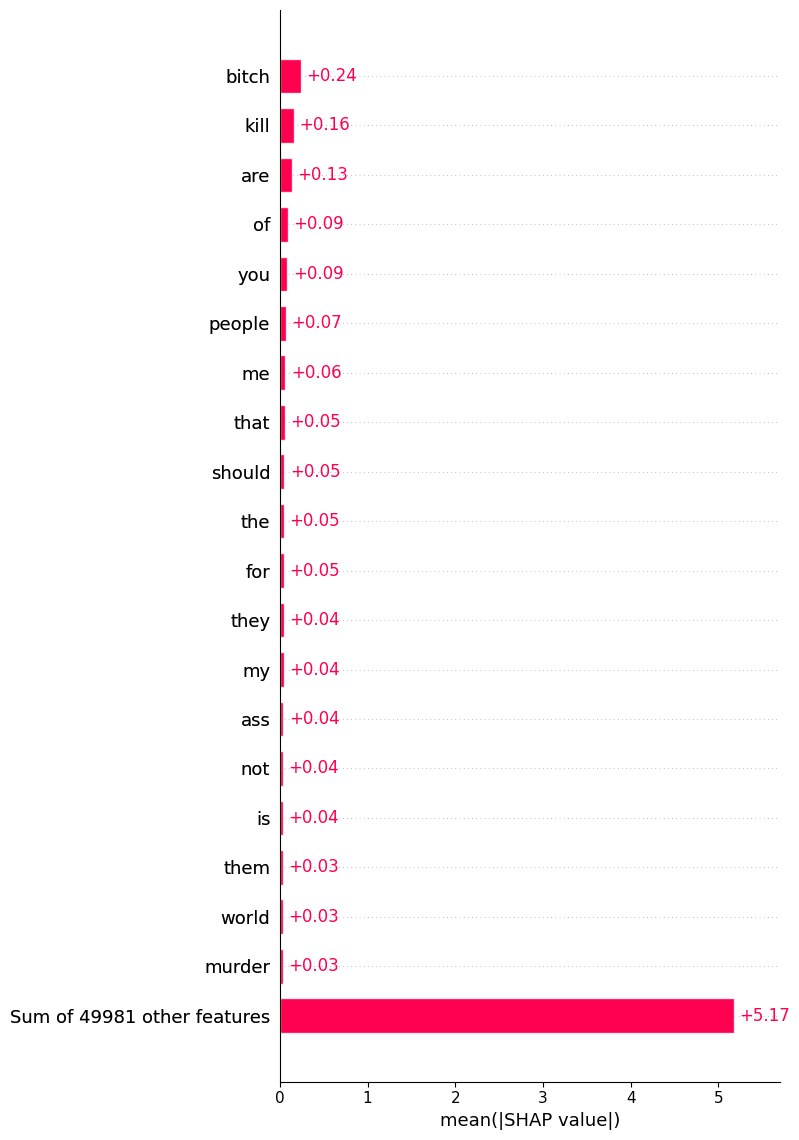

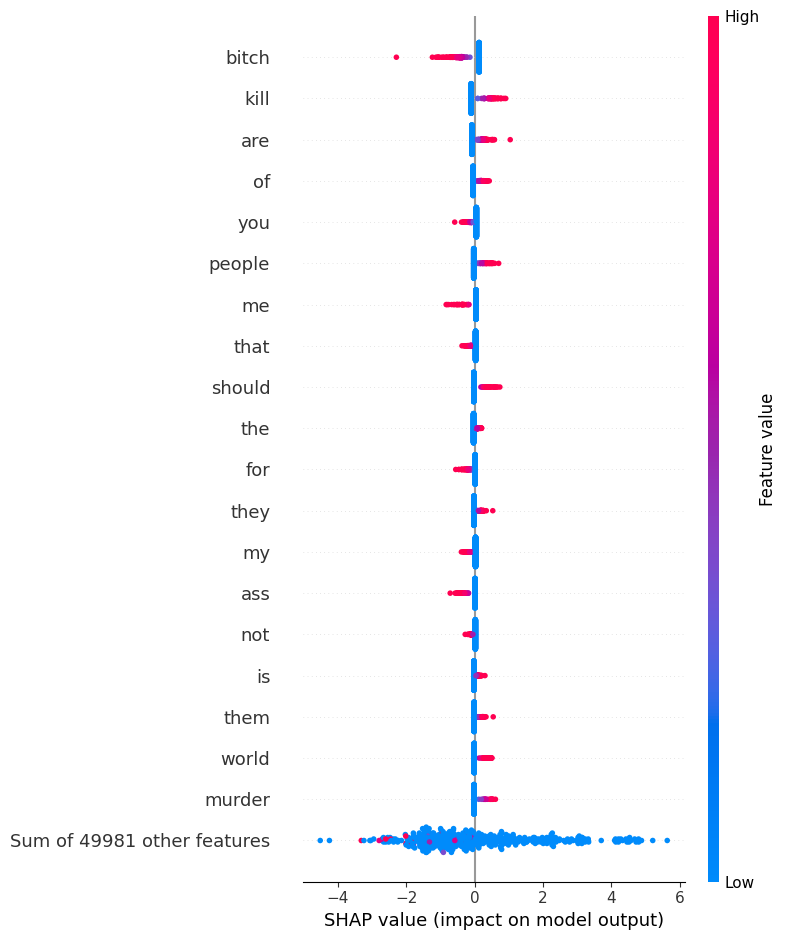

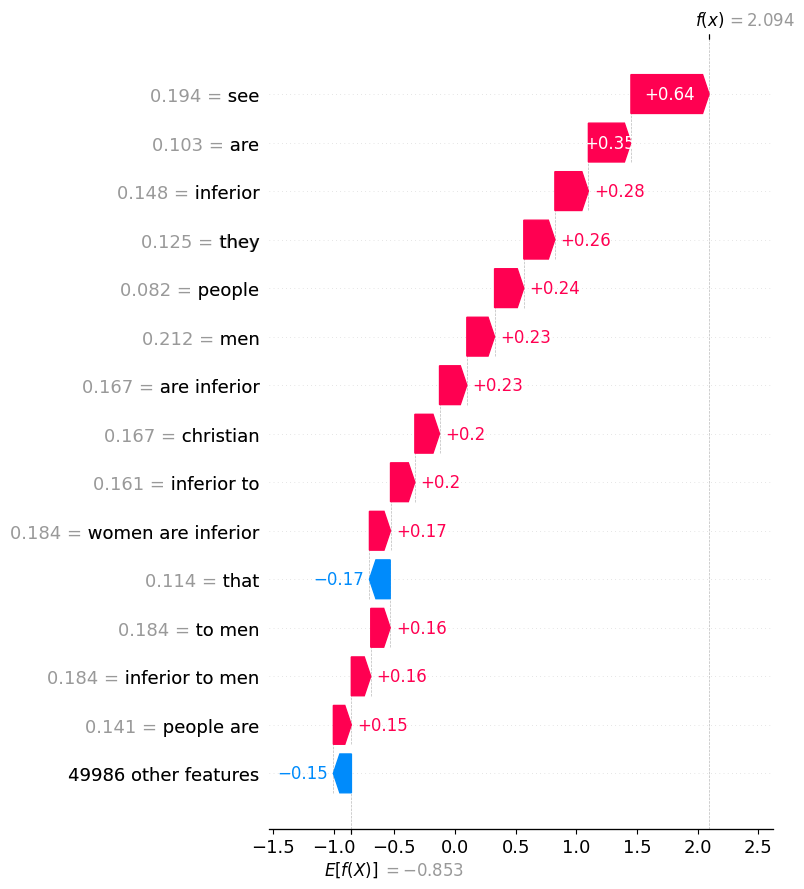

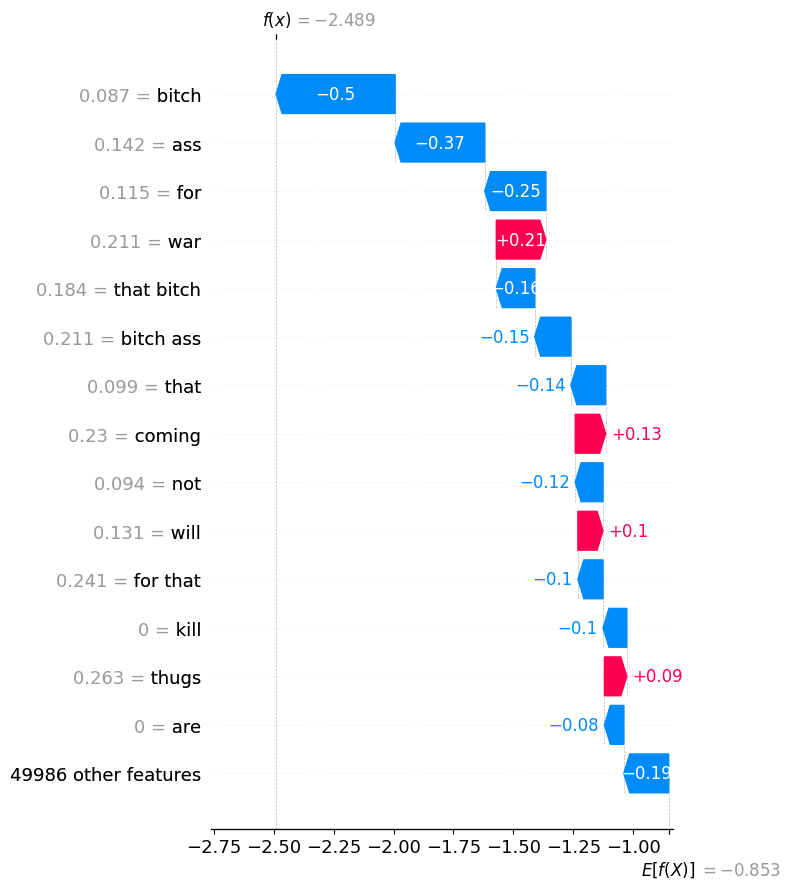

Saved SHAP graphs to: /kaggle/working/experiments/LOG-REG_TF-IDF/interpretability/shap


In [41]:
# ============================================================
# 17b. SHAP analysis (exact linear-kernel explainer)
# ============================================================
# shap.LinearExplainer computes EXACT Shapley values for a linear decision
# function -- no sampling, no approximation. This is the same math as the
# hand-derived contribution tables above, computed through the shap library
# so its standard plots (bar / beeswarm / waterfall) are available. The two
# should agree numerically; this cell does not replace the earlier tables.
#
# Explains: LogisticRegression logit (log-odds) contribution

import subprocess
import sys

try:
    import shap
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "shap"])
    import shap

shap_dir = OUTPUT_DIR / "interpretability" / "shap"
shap_dir.mkdir(parents=True, exist_ok=True)

# Background dataset: a random sample of TRAIN rows only (never validation/test).
# This is the "typical" reference point the explainer measures deviation from.
SHAP_BACKGROUND_SIZE = 100
shap_rng = np.random.default_rng(CONFIG["random_seed"])
shap_background_idx = shap_rng.choice(
    X_train_final.shape[0],
    size=min(SHAP_BACKGROUND_SIZE, X_train_final.shape[0]),
    replace=False,
)
shap_background = X_train_final[shap_background_idx]

shap_explainer = shap.LinearExplainer(
    final_model,
    shap_background,
    feature_perturbation="interventional",
)

# Closed-form for a linear model: scoring the full test split costs nothing extra.
shap_explanation = shap_explainer(X_test_final)
shap_explanation.feature_names = feature_names.tolist()

print("SHAP values computed. Shape:", shap_explanation.values.shape)

# ---- Data: global importance ranking ----
global_shap_importance = pd.DataFrame({
    "feature_name": feature_names,
    "mean_abs_shap": np.abs(shap_explanation.values).mean(axis=0),
    "mean_shap": shap_explanation.values.mean(axis=0),
})
global_shap_importance = global_shap_importance.sort_values(
    "mean_abs_shap", ascending=False
).reset_index(drop=True)
global_shap_importance.to_csv(shap_dir / "global_shap_importance.csv", index=False)

# ---- Data: full per-example SHAP values for the test split ----
shap_values_df = pd.DataFrame(shap_explanation.values, columns=feature_names)
shap_values_df.insert(0, "row_id", test_df[id_col].values)
try:
    shap_values_df.to_parquet(shap_dir / "shap_values_test.parquet", index=False)
except Exception as parquet_error:
    print("Parquet save failed, falling back to CSV:", parquet_error)
    shap_values_df.to_csv(shap_dir / "shap_values_test.csv", index=False)

joblib.dump(shap_explanation, shap_dir / "shap_explanation_object.pkl")

save_json(
    {
        "method": "shap.LinearExplainer",
        "feature_perturbation": "interventional",
        "background_split": "train",
        "background_sample_size": int(len(shap_background_idx)),
        "explains": "LogisticRegression logit (log-odds) contribution",
        "n_test_rows_explained": int(shap_explanation.values.shape[0]),
        "n_features": int(shap_explanation.values.shape[1]),
    },
    shap_dir / "shap_metadata.json",
)

print("Saved SHAP data outputs to:", shap_dir)

# ---- Graphs: global ----
plt.figure()
shap.plots.bar(shap_explanation, max_display=20, show=False)
plt.tight_layout()
plt.savefig(shap_dir / "shap_bar_global.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
shap.plots.beeswarm(shap_explanation, max_display=20, show=False)
plt.tight_layout()
plt.savefig(shap_dir / "shap_beeswarm_global.png", dpi=200, bbox_inches="tight")
plt.show()

# ---- Graphs: local waterfalls for the same high-confidence error examples ----
# selected earlier in the local-interpretability cell above.
waterfall_targets = (
    selected_pred_examples[
        selected_pred_examples["selection_bucket"].isin(
            ["high_confidence_false_positive", "high_confidence_false_negative"]
        )
    ]
    .groupby("selection_bucket", group_keys=False)
    .head(1)
)

for _, row in waterfall_targets.iterrows():
    pos = test_row_position[row["row_id"]]
    plt.figure()
    shap.plots.waterfall(shap_explanation[pos], max_display=15, show=False)
    plt.tight_layout()
    fname = f"shap_waterfall_{row['selection_bucket']}_{row['row_id']}.png"
    plt.savefig(shap_dir / fname, dpi=200, bbox_inches="tight")
    plt.show()

print("Saved SHAP graphs to:", shap_dir)


In [18]:
# ============================================================
# 18. Error-analysis outputs
# ============================================================

error_df = test_predictions.copy()
error_df["abs_distance_to_threshold"] = np.abs(error_df["y_prob"] - error_df["threshold"])

def confidence_bucket(row):
    if row["abs_distance_to_threshold"] <= CONFIG["error_analysis"]["near_threshold_margin"]:
        return "near_threshold"
    if row["y_prob"] >= 0.90 or row["y_prob"] <= 0.10:
        return "high_confidence"
    return "moderate_confidence"

error_df["confidence_bucket"] = error_df.apply(confidence_bucket, axis=1)
error_df["manual_error_category"] = ""
error_df["manual_notes"] = ""

# Attach local top features if available.
if not local_explanations.empty:
    feature_cols = local_explanations[
        ["row_id", "top_positive_features_json", "top_negative_features_json"]
    ].drop_duplicates("row_id")
    error_df = error_df.merge(feature_cols, on="row_id", how="left")

if CONFIG["error_analysis"]["include_text_preview"]:
    text_lookup = test_df[[id_col, text_col]].copy()
    text_lookup["text_preview"] = text_lookup[text_col].str.slice(0, CONFIG["error_analysis"]["text_preview_chars"])
    error_df = error_df.merge(text_lookup[[id_col, "text_preview"]], left_on="row_id", right_on=id_col, how="left")
    if id_col in error_df.columns and id_col != "row_id":
        error_df = error_df.drop(columns=[id_col])

error_df.to_csv(OUTPUT_DIR / "error_analysis" / "error_analysis_test.csv", index=False)

# A smaller review file focused on important cases.
review_parts = []
n = CONFIG["error_analysis"]["examples_per_bucket"]

review_parts.append(
    error_df[error_df["error_type"] == "false_positive"]
    .sort_values("y_prob", ascending=False)
    .head(n)
    .assign(review_bucket="highest_confidence_false_positive")
)

review_parts.append(
    error_df[error_df["error_type"] == "false_negative"]
    .sort_values("y_prob", ascending=True)
    .head(n)
    .assign(review_bucket="highest_confidence_false_negative")
)

review_parts.append(
    error_df[error_df["error_type"] == "false_positive"]
    .sort_values("abs_distance_to_threshold", ascending=True)
    .head(n)
    .assign(review_bucket="near_threshold_false_positive")
)

review_parts.append(
    error_df[error_df["error_type"] == "false_negative"]
    .sort_values("abs_distance_to_threshold", ascending=True)
    .head(n)
    .assign(review_bucket="near_threshold_false_negative")
)

selected_review_examples = (
    pd.concat(review_parts, axis=0)
    .drop_duplicates(subset=["row_id"])
    .reset_index(drop=True)
)

selected_review_examples.to_csv(
    OUTPUT_DIR / "error_analysis" / "selected_examples_for_review.csv",
    index=False,
)

print("Saved error analysis files:")
print("-", OUTPUT_DIR / "error_analysis" / "error_analysis_test.csv")
print("-", OUTPUT_DIR / "error_analysis" / "selected_examples_for_review.csv")

display(error_df["error_type"].value_counts().to_frame("count"))
display(error_df.groupby(["error_type", "confidence_bucket"]).size().reset_index(name="count"))

Saved error analysis files:
- /kaggle/working/experiments/LOG-REG_TF-IDF/error_analysis/error_analysis_test.csv
- /kaggle/working/experiments/LOG-REG_TF-IDF/error_analysis/selected_examples_for_review.csv


,count
error_type,
true_negative,250
true_positive,134
false_negative,36
false_positive,30


,error_type,confidence_bucket,count
0,false_negative,high_confidence,2
1,false_negative,moderate_confidence,32
2,false_negative,near_threshold,2
3,false_positive,moderate_confidence,26
4,false_positive,near_threshold,4
5,true_negative,high_confidence,125
6,true_negative,moderate_confidence,118
7,true_negative,near_threshold,7
8,true_positive,high_confidence,60
9,true_positive,moderate_confidence,70


In [19]:
# ============================================================
# 19. Save experiment metadata and output README
# ============================================================

metadata = {
    "run_id": RUN_ID,
    "technique": TECHNIQUE_NAME,
    "created_at_utc": dt.datetime.utcnow().replace(microsecond=0).isoformat() + "Z",
    "project_name": CONFIG["project_name"],
    "dataset_version": CONFIG["dataset_version"],
    "split_version": CONFIG["split_version"],
    "random_seed": CONFIG["random_seed"],
    "processed_dataset_path": str(processed_dataset_path),
    "processed_dataset_sha256_16": sha256_file(processed_dataset_path),
    "split_assignments_path": str(split_assignments_path),
    "split_assignments_sha256_16": sha256_file(split_assignments_path),
    "dataset_manifest": dataset_manifest,
    "software_environment": {
        "python_version": platform.python_version(),
        "platform": platform.platform(),
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
    },
    "sklearn_version": __import__("sklearn").__version__,
    "model_selection": {
        "ablation_split": "validation",
        "primary_selection_metric": "positive_f1",
        "test_set_used_for_selection": False,
    },
    "final_evaluation": {
        "test_split_used_once_after_selection": True,
        "threshold_selected_on": "validation",
    },
    "outputs": {
        "config": "config.json",
        "best_config": "best_config.json",
        "ablation_results": "ablation/ablation_results.csv",
        "metrics_validation": "metrics_validation.json",
        "metrics_test": "metrics_test.json",
        "predictions_validation": "predictions_validation.csv",
        "predictions_test": "predictions_test.csv",
        "model_artifacts": "model_artifacts/",
        "plots": "plots/",
        "interpretability": "interpretability/",
        "error_analysis": "error_analysis/",
    },
}

save_json(metadata, OUTPUT_DIR / "metadata.json")

readme_text = f"""# {TECHNIQUE_NAME} outputs

This folder contains the standardized outputs for the `{TECHNIQUE_NAME}` experiment.

## Research protocol

- Dataset: `{CONFIG['dataset_version']}`
- Split version: `{CONFIG['split_version']}`
- Model selection: validation-only
- Primary selection metric: validation positive-class F1
- Threshold selection: validation-only
- Final test evaluation: held-out test split only

## Key files

- `metrics_test.json`: final held-out test metrics
- `predictions_test.csv`: standardized row-level test predictions
- `ablation/ablation_results.csv`: validation-only tuning results
- `best_config.json`: selected model configuration
- `model_artifacts/`: trained model/vectorizer/feature names/threshold
- `interpretability/`: global and local feature-contribution outputs
- `error_analysis/`: tables for false-positive/false-negative review
"""

with open(OUTPUT_DIR / "README_outputs.md", "w") as f:
    f.write(readme_text)

print("Saved metadata and output README.")
print("Output directory:", OUTPUT_DIR)

Saved metadata and output README.
Output directory: /kaggle/working/experiments/LOG-REG_TF-IDF


/tmp/ipykernel_23/980761567.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at_utc": dt.datetime.utcnow().replace(microsecond=0).isoformat() + "Z",


In [20]:
# ============================================================
# 20. Zip outputs for download / Google Drive storage
# ============================================================

zip_base = Path("/kaggle/working") / f"{TECHNIQUE_NAME}_outputs"
zip_path = shutil.make_archive(
    base_name=str(zip_base),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("Created zip file:")
print(zip_path)

Created zip file:
/kaggle/working/LOG-REG_TF-IDF_outputs.zip
